# EMAIL SPAM DETECTION WITH MACHINE LEARNING
In this Project, use **Python** to build an **email spam detector**. Then, use machine learning to train the spam detector to **recognize** and **classify** emails into **spam** and **non-spam**. Let's get started!

## About Dataset
#### Context
The SMS Spam Collection is a set of SMS tagged messages that have been collected for SMS Spam research. It contains one set of SMS messages in English of 5,574 messages, tagged acording being ham (legitimate) or spam.

#### Content
The files contain one message per line. Each line is composed by two columns: v1 contains the label (ham or spam) and v2 contains the raw text.

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Description

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')[['v1','v2']]
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.describe()

,v1,v2
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


## Data Preprocessing

### 1. Rename Columns

In [4]:
df.columns = ['Label', 'Message']
df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 2. Check **Duplicates**

In [5]:
df.duplicated().sum()

403

#### Remove **Duplicates**

In [6]:
df.drop_duplicates(inplace=True)

### Check **Missing Values**

In [7]:
df.isna().sum()

Label      0
Message    0
dtype: int64

## Exploratory Data Analysis (EDA)

In [8]:
# manually adding annotations to each bar
def annotate_bars(ax):
    for p in ax.patches:
        count = int(p.get_height())
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.text(x, y, str(count), ha='center', va='bottom')

### Label Distribution

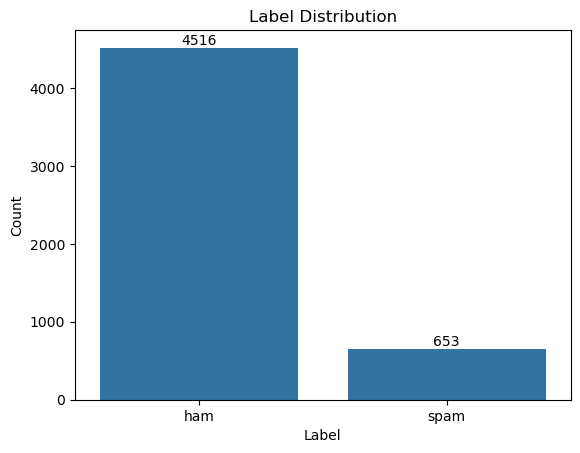

In [9]:
ax = sns.countplot(data=df, x='Label')
plt.title("Label Distribution")
plt.xlabel('Label')
plt.ylabel('Count')

annotate_bars(ax)

#### This figure show that **non-spam** is more popular than spam. 

## Text Preprocessing

### Encode Labels

In [10]:
df['Label'] = df['Label'].map({"ham": 0, "spam": 1})
df['Label'].value_counts()

Label
0    4516
1     653
Name: count, dtype: int64

### Clean text (remove punctuation, lowercase)
- to avoid case-sensitive duplicates like "Spam" and "spam"
- Removing non-word characters (\W+ matches anything that's not a letter, digit, or underscore).

In [11]:
import re
def clean_text(text):
    return re.sub(r'\W+', ' ', text.lower())

df['Message'] = df['Message'].apply(clean_text)

### Bag of Words (BoW) Vectorization
Convert Text to Numbers (Each message becomes a vector of word counts)

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

In [13]:
# Bag of Words
cv = CountVectorizer()
X = cv.fit_transform(df['Message'])

In [14]:
# Labels
y = df['Label'].values

#### Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling (Multinomial Naive Bayes Model)
#### ✅ Why `MultinomialNB` is a Good Choice Here

- `MultinomialNB` works best with **discrete count data**, such as the word counts generated by `CountVectorizer`.
- It assumes that the features follow a **multinomial distribution**, which is a good approximation for text data represented as **Bag of Words**.
- `MultinomialNB` is **computationally inexpensive**, making it well-suited for **real-time** or **large-scale** applications.
- Performs especially well in **binary** or **multi-class** text classification problems.

---

### 🔁 When *Not* to Use `MultinomialNB`:
- If features are **continuous** (e.g., raw numerical values or **TF-IDF** scores without binning).

In [16]:
from sklearn.naive_bayes import MultinomialNB

### Training

In [17]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

### Evaluation

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [19]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.98
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       889
           1       0.94      0.94      0.94       145

    accuracy                           0.98      1034
   macro avg       0.96      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



#### Confusion Matrix

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

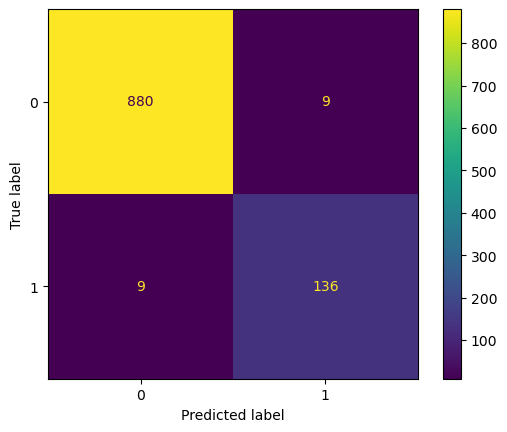

In [21]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred)) 
disp.plot() 

#### Save Model

In [22]:
import joblib

joblib.dump(model, 'spam_detect_model.pkl')

['spam_detect_model.pkl']